← [Cómo se mide](11-como-se-mide.ipynb) · [Índice](00-indice.ipynb)

# 12 · Del modelo al robot

Entrenar produce un modelo de Keras. Lo que corre en el servicio es otra cosa.
Este documento cubre esa traducción, donde se pierde más de lo que parece.



## Por qué TensorFlow Lite

Un modelo de Keras necesita TensorFlow completo: cientos de megabytes, arranque
lento, pensado para entrenar. Para **solo predecir** no hace falta nada de eso.

**TensorFlow Lite** es un formato de despliegue: un solo archivo `.tflite` con
la estructura y los pesos, ejecutable por un intérprete ligero.

`vision/local_model.py` intenta tres runtimes en orden y usa el primero que
encuentre:

```python
ai-edge-litert  →  tflite-runtime  →  tensorflow
```

Si ninguno está disponible o el archivo falla, el servicio **sigue funcionando**
con el proveedor de visión y el sistema experto. La red neuronal es un voto que
puede faltar, no una dependencia dura.



## Cuantización

Un modelo entrenado guarda cada parámetro como un número de coma flotante de 32
bits. La **cuantización** los convierte a enteros de 8 bits.

```
float32  →  int8
4 bytes     1 byte      ≈ 4× menos espacio, aritmética más rápida
```

Naturalmente se pierde precisión: donde había 4.300 millones de valores
posibles, quedan 256. La apuesta es que un modelo entrenado tiene redundancia de
sobra y esa pérdida no cambia sus predicciones.

**A veces la apuesta falla.** Y ese es el punto de este documento.



## El criterio 4 y por qué existe

La propuesta de nuevo modelo exige "sin regresión relevante después de la
exportación a TFLite". Durante un tiempo **no se estaba comprobando**: se medían
tamaño, formas y latencia del artefacto, pero nunca su exactitud.

El agujero es serio, porque toda la selección de modelo se hace sobre el modelo
de Keras en float32, mientras lo que se despliega es el `.tflite` cuantizado. Si
son distintos, se elige uno y se instala otro.

`exportacion.py` lo cierra con `medir_regresion_cuantizacion()`: ejecuta ambos
sobre las mismas imágenes de validación y compara.



## El resultado, medido

| Arquitectura | Acuerdo f32 ↔ int8 | Caída de macro-F1 |
| --- | ---: | ---: |
| MobileNetV2 | 98,5 % | 0,017 |
| EfficientNet-B0 | 57,4 % | 0,232 |
| MobileNetV3-Large | 47,1 % | 0,350 |

MobileNetV2 sobrevive. Los otros dos se rompen: MobileNetV3-Large cambia de
opinión en **más de la mitad** de las imágenes al cuantizarse.

### La causa: la activación

Una **activación** es la función que decide qué pasa de una capa a la siguiente.
Cada arquitectura usa la suya:

| Arquitectura | Activación | ¿Acotada? |
| --- | --- | --- |
| MobileNetV2 | ReLU6 | **Sí**, entre 0 y 6 |
| EfficientNet-B0 | Swish | No |
| MobileNetV3-Large | hard-swish | No |

Cuantizar a int8 significa repartir 256 valores sobre el rango que los números
puedan tomar. Si el rango está **acotado** —ReLU6 nunca pasa de 6— esos 256
valores cubren un espacio pequeño y quedan finos. Si no está acotado, hay que
estirarlos sobre un rango amplio y cada paso se vuelve grueso.

ReLU6 no lleva ese 6 por casualidad: MobileNetV2 se diseñó pensando en
cuantizar.



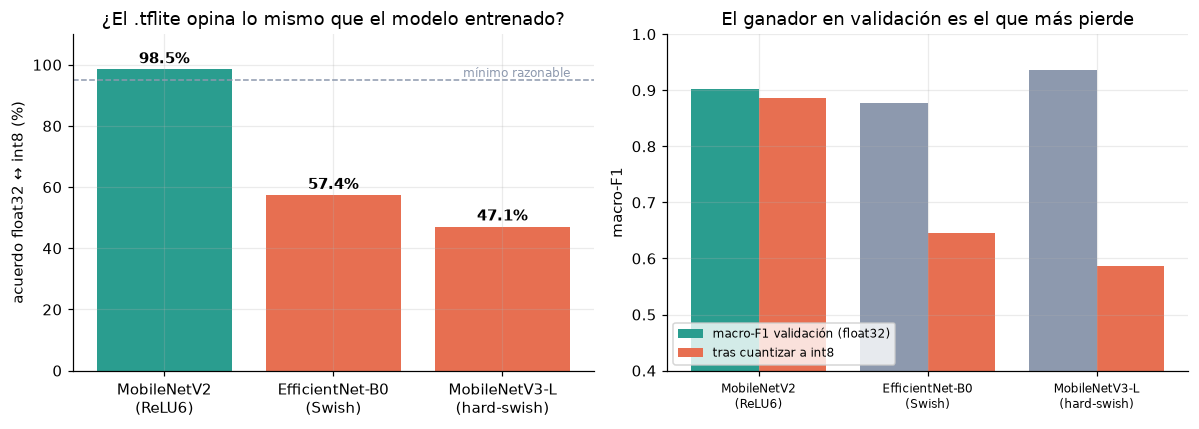

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

VIDRIO, PLASTICO, GRIS, ALERTA = "#2a9d8f", "#e9c46a", "#8d99ae", "#e76f51"
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
})

# Cuantizar a int8 no afecta igual a todas las arquitecturas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

arqs = ["MobileNetV2\n(ReLU6)", "EfficientNet-B0\n(Swish)", "MobileNetV3-L\n(hard-swish)"]
acuerdo = [98.5, 57.4, 47.1]
caida = [0.017, 0.232, 0.350]
colores = [VIDRIO, ALERTA, ALERTA]

barras = ax1.bar(arqs, acuerdo, color=colores)
ax1.axhline(95, ls="--", color=GRIS, lw=1)
ax1.text(2.4, 96, "mínimo razonable", fontsize=8, color=GRIS, ha="right")
ax1.set(ylabel="acuerdo float32 ↔ int8 (%)", ylim=(0, 110),
        title="¿El .tflite opina lo mismo que el modelo entrenado?")
for b, v in zip(barras, acuerdo):
    ax1.text(b.get_x() + b.get_width()/2, v + 2, f"{v}%", ha="center", weight="bold")

# Lo que gana en validación frente a lo que pierde al cuantizar
val = [0.9028, 0.8775, 0.9363]
ax2.bar(np.arange(3) - 0.2, val, 0.4, label="macro-F1 validación (float32)",
        color=[VIDRIO, GRIS, GRIS])
ax2.bar(np.arange(3) + 0.2, [v - c for v, c in zip(val, caida)], 0.4,
        label="tras cuantizar a int8", color=ALERTA)
ax2.set_xticks(range(3)); ax2.set_xticklabels(arqs, fontsize=8)
ax2.set(ylabel="macro-F1", ylim=(0.4, 1.0),
        title="El ganador en validación es el que más pierde")
ax2.legend(fontsize=8, loc="lower left")

plt.tight_layout(); plt.show()

## La consecuencia práctica

Es el ejemplo más claro de la serie sobre por qué hay que medir lo que de verdad
se despliega:

> **MobileNetV3-Large gana en validación (0,9363) y es el peor candidato
> desplegable en int8.**

Elegir por la métrica de validación —sin mirar el artefacto— habría instalado en
el robot un modelo que en la práctica funciona peor que el que ya estaba.

Salidas posibles: exportar esos dos en **float16** (menos compresión, menos
pérdida), o entrenarlos con *quantization-aware training*, que simula la
cuantización durante el entrenamiento para que el modelo se adapte.



## Integración segura

El protocolo para probar un candidato sin arriesgar el robot:

1. Exportar el TFLite con el preprocesamiento incluido
   ([07](07-transfer-learning-y-mobilenet.ipynb)).
2. Conservar exactamente las etiquetas `plastico` y `vidrio` — `local_model.py`
   rechaza cualquier otra lista.
3. Cargarlo por variable de entorno, **sin sobrescribir** `model.tflite`:

```bash
LOCAL_MODEL_PATH=model/runs/<corrida>/model.tflite
LOCAL_MODEL_LABELS=model/runs/<corrida>/labels.txt
```

4. Ejecutar las pruebas del servicio y de votación.
5. Desplegar en **modo sombra**: registrar su predicción sin dejar que cambie la
   decisión del robot.
6. Comparar todas las señales sobre las mismas capturas.
7. Cambiar la política de voto solo después de aprobar las métricas.

El modo sombra del paso 5 es la idea que cierra el círculo de toda la serie:
antes de confiar en un modelo, se le deja opinar sin consecuencias y se comprueba
si tenía razón.



## El resumen de la serie

Si hay que quedarse con cinco frases:

1. El error tiene costo físico, así que **abstenerse es barato y equivocarse es
   caro**.
2. Sistema experto y red neuronal **fallan por motivos distintos**, y por eso se
   combinan.
3. Una métrica solo vale si se midió en el **dominio real** del robot.
4. La **confianza de una red no mide si tiene razón**.
5. Hay que medir el **artefacto que se despliega**, no el modelo que se entrenó.

---

← [Cómo se mide](11-como-se-mide.ipynb) · [Índice](00-indice.ipynb)
